In [1]:
import fastparquet as fp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils.make_paths_absolute


sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [2]:
files = [
    "phase2_results.parquet",
    "phase2_11_to_14_results.parquet",
    "phase2_18_qubits_high_confidence_results.parquet",
    "phase2_22_qubits_high_confidence_results.parquet",
]
combined_df = pd.concat(
    [pd.read_parquet(f"outputs/prev_in_phase2/{file}", engine="fastparquet") for file in files],
    ignore_index=True,
)
combined_df

,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification
0,0,"[1, 0, 1, 0, 1, 0, 0, 0, 0]",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
1,1,"[1, 0, 1, 0, 1, 0, 0, 0, 0]",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
2,2,"[1, 0, 1, 0, 1, 0, 0, 0, 0]",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
3,3,"[1, 0, 1, 0, 1, 0, 0, 0, 0]",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
4,4,"[1, 0, 1, 0, 1, 0, 0, 0, 0]",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
...,...,...,...,...,...,...,...,...,...,...
1825,25,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, ...",153.002790,0.079294,AF-5PTI,53_60,8,7,22,tie
1826,26,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",153.974535,1.051038,AF-5PTI,53_60,8,7,22,tie
1827,27,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, ...",153.804590,0.881094,AF-5PTI,53_60,8,7,22,tie
1828,28,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",153.974535,1.051038,AF-5PTI,53_60,8,7,22,tie


In [3]:
one_hot_classifications = pd.get_dummies(combined_df.classification)
combined_df = pd.concat([combined_df, one_hot_classifications], axis=1)

combined_df["starting_residue"] = combined_df.residues.apply(lambda x: int(x.split("_")[0]))
combined_df["ending_residue"] = combined_df.residues.apply(lambda x: int(x.split("_")[1]))


grouped_df = combined_df.groupby(["residues", "residue_count"]).agg({"energy_diff": ["min", "max", 'mean', "std"]}).reset_index()

grouped_df["starting_residue"] = grouped_df.residues.apply(lambda x: int(x.split("_")[0]))
grouped_df["ending_residue"] = grouped_df.residues.apply(lambda x: int(x.split("_")[1]))

grouped_df.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in grouped_df.columns
]
grouped_df

,residues,residue_count,energy_diff_min,energy_diff_max,energy_diff_mean,energy_diff_std,starting_residue,ending_residue
0,50_54,5,-1.988043,-1.315741,-1.901158,0.172081,50,54
1,50_55,6,-1.209768,0.408408,-0.782379,0.390146,50,55
2,51_55,5,-1.046325,0.503157,-0.459921,0.519398,51,55
3,51_58,8,-0.691103,0.652349,-0.208425,0.466756,51,58
4,52_55,4,-1.001821,-0.329536,-0.893581,0.190907,52,55
5,52_57,6,-0.759543,-0.071009,-0.649988,0.183868,52,57
6,52_58,7,-0.646598,1.117873,-0.161707,0.494438,52,58
7,53_56,4,0.484693,2.632774,0.689906,0.439728,53,56
8,53_57,5,0.000979,3.244365,0.191350,0.475983,53,57
9,53_60,8,0.079294,4.392708,1.192356,1.158360,53,60


In [4]:
combined_df.energy_diff.nunique()
reside_counts = grouped_df.residue_count.unique()

In [5]:
# Add column to combined_df for qubit count category
def qubit_category(num_qubits):
    if num_qubits <= 14:
        return "<=14"
    elif num_qubits == 18:
        return "18"
    elif num_qubits == 22:
        return "22"
combined_df["qubit_category"] = combined_df.num_qubits.apply(qubit_category)

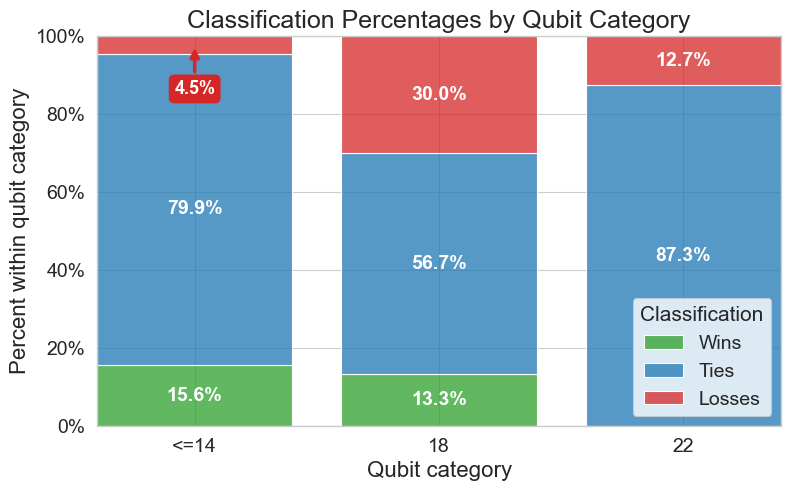

In [6]:
from matplotlib.ticker import FuncFormatter

order = ["<=14", "18", "22"]
hue_order = ["loss", "tie", "win"]
palette = {"win": "#2ca02c", "tie": "#1f77b4", "loss": "#d62728"}

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=combined_df,
    x="qubit_category",
    hue="classification",

    # order=order,
    hue_order=["loss", "tie", "win"],
    palette=palette,

    discrete=True,
    shrink=0.8,
    multiple="fill",
    stat="count",
    ax=ax,
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.set_ylabel("Percent within qubit category", fontsize=16)
ax.set_xlabel("Qubit category", fontsize=16)
ax.set_ylim(0, 1)
ax.set_title("Classification Percentages by Qubit Category", fontsize=18)
ax.legend(title="Classification", labels=["Wins", "Ties", "Losses"], fontsize=14, title_fontsize=15)
ax.tick_params(axis="both", labelsize=14)

for p in ax.patches:
    h = p.get_height()
    if np.isnan(h) or h <= 0:
        continue

    # Only label meaningful segments to avoid clutter (e.g., >5%)
    if h >= 0.05:
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + h / 2
        ax.text(
            x, y, f"{h*100:.1f}%",
            ha="center", va="center",
            color="white", fontsize=14, fontweight="bold"
        )

# Annotate the tiny 4.5% segment (<=14 wins) with an arrow from below
for p in ax.patches:
    h = p.get_height()
    if np.isnan(h) or h <= 0:
        continue
    if 0.03 < h < 0.05:
        x = p.get_x() + p.get_width() / 2
        y_tip = p.get_y() + h / 2
        ax.annotate(
            f"{h*100:.1f}%",
            xy=(x, y_tip),
            xytext=(x, y_tip - 0.09),
            ha="center", va="top",
            color="white", fontsize=13, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="#d62728", ec="none"),
            arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=2.5),
        )

plt.tight_layout()

plt.savefig("plots/classification_percentages_by_qubit_category.svg", dpi=300, bbox_inches="tight")
plt.show()